In [6]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

## ARIMA for “Manufacturing”

Manufacturing | ARIMA RMSE: 71829.10, MAPE: 0.50%, Growth: -0.00%


/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_3279/81951085.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


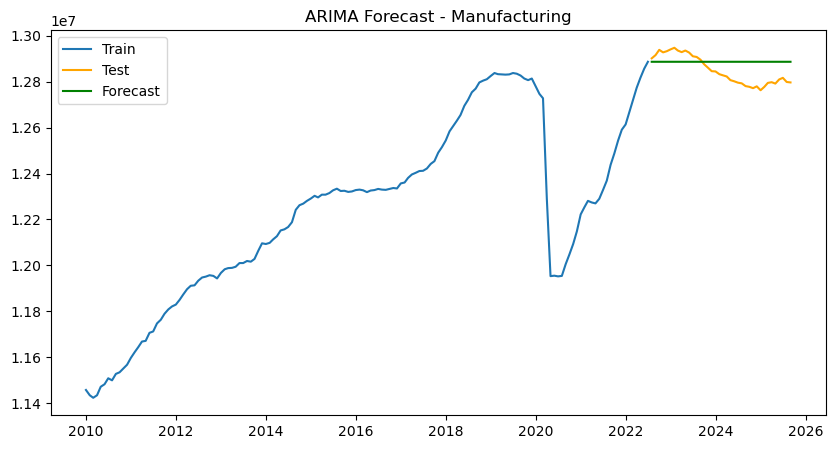

Results saved successfully to arima_forecasts.csv


In [8]:
# --- Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Select industry ---
industry = 'Manufacturing'
y = df[industry]

# --- Train-test split ---
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# --- Fit ARIMA ---
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

# --- Forecast ---
forecast = model_fit.forecast(steps=len(test))

# --- Evaluate ---
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
growth_rate = ((forecast.iloc[-1] - train.iloc[-1]) / train.iloc[-1]) * 100
print(f'{industry} | ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2%}, Growth: {growth_rate:.2f}%')

# --- Plot ---
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title(f'ARIMA Forecast - {industry}')
plt.legend()
plt.show()

# --- Save results ---
results = [{
    'Industry': industry,
    'ARIMA_RMSE': rmse,
    'ARIMA_MAPE': mape,
    'ARIMA_Growth_%': growth_rate
}]

arima_results_df = pd.DataFrame(results)
output_AR = 'arima_forecasts.csv'  # Save in notebook folder
arima_results_df.to_csv(output_AR, index=False)
print(f'Results saved successfully to {output_AR}')


## ARIMA for “Trade, transportation, and utilities”

Trade, transportation, and utilities | ARIMA RMSE: 354346.51, MAPE: 1.18%, Growth: -0.0019%


/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_3279/80358501.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


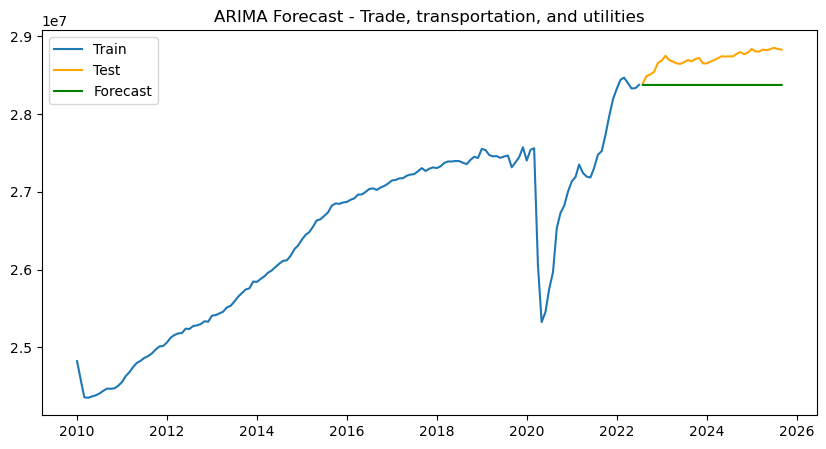

Added results for "Trade, transportation, and utilities" to arima_forecasts.csv successfully!
                               Industry     ARIMA_RMSE  ARIMA_MAPE  \
0                         Manufacturing   71829.104330    0.005027   
1  Trade, transportation, and utilities  354346.510694    0.011810   

   ARIMA_Growth_%  
0       -0.000051  
1       -0.001944  


In [12]:
# --- Step 1: Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Step 2: Select new industry ---
industry = 'Trade, transportation, and utilities'
y = df[industry]

# --- Step 3: Train-test split ---
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# --- Step 4: Fit ARIMA model ---
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# --- Step 5: Forecast ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 6: Evaluate performance ---
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
growth_rate = ((forecast.iloc[-1] - train.iloc[-1]) / train.iloc[-1]) * 100

print(f'{industry} | ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2%}, Growth: {growth_rate:.4f}%')

# --- Step 7: Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title(f'ARIMA Forecast - {industry}')
plt.legend()
plt.show()

# --- Step 8: Prepare result record ---
new_result = pd.DataFrame([{
    'Industry': industry,
    'ARIMA_RMSE': rmse,
    'ARIMA_MAPE': mape,
    'ARIMA_Growth_%': growth_rate
}])

# --- Step 10: Save updated results ---
updated_results.to_csv(existing_file, index=False)
print(f'Added results for "{industry}" to {existing_file} successfully!')
print(updated_results)


## Education And Health Services

Education and health services | ARIMA RMSE: 1608740.83, MAPE: 5.75%, Growth: 0.0001%


/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_3279/643728484.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


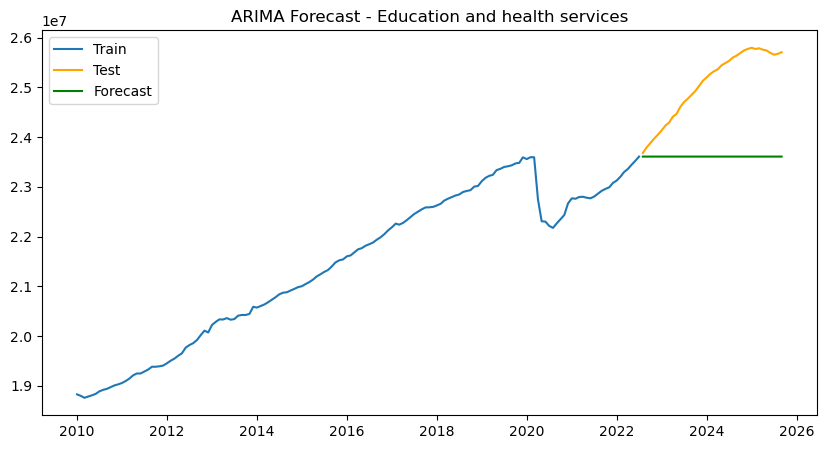

Added results for "Education and health services" to arima_forecasts.csv successfully!
                               Industry    ARIMA_RMSE  ARIMA_MAPE  \
0                         Manufacturing  7.182910e+04    0.005027   
1  Trade, transportation, and utilities  3.543465e+05    0.011810   
2         Education and health services  1.608741e+06    0.057536   

   ARIMA_Growth_%  
0       -0.000051  
1       -0.001944  
2        0.000086  


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- Step 1: Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Step 2: Select new industry ---
industry = 'Education and health services'
y = df[industry]

# --- Step 3: Train-test split ---
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# --- Step 4: Fit ARIMA model ---
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# --- Step 5: Forecast ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 6: Evaluate performance ---
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
growth_rate = ((forecast.iloc[-1] - train.iloc[-1]) / train.iloc[-1]) * 100

print(f'{industry} | ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2%}, Growth: {growth_rate:.4f}%')

# --- Step 7: Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title(f'ARIMA Forecast - {industry}')
plt.legend()
plt.show()

# --- Step 8: Prepare result record ---
new_result = pd.DataFrame([{
    'Industry': industry,
    'ARIMA_RMSE': rmse,
    'ARIMA_MAPE': mape,
    'ARIMA_Growth_%': growth_rate
}])

# --- Step 9: Append to existing file ---
existing_file = 'arima_forecasts.csv'

try:
    # Load existing results if file exists
    existing_results = pd.read_csv(existing_file)
    updated_results = pd.concat([existing_results, new_result], ignore_index=True)
except FileNotFoundError:
    # If file doesn't exist, start fresh
    updated_results = new_result

# --- Step 10: Save updated results ---
updated_results.to_csv(existing_file, index=False)
print(f'Added results for "{industry}" to {existing_file} successfully!')
print(updated_results)


## Professional and business services

Professional and business services | ARIMA RMSE: 1026244.19, MAPE: 3.94%, Growth: 6.6794%


/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_3279/652277406.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohi

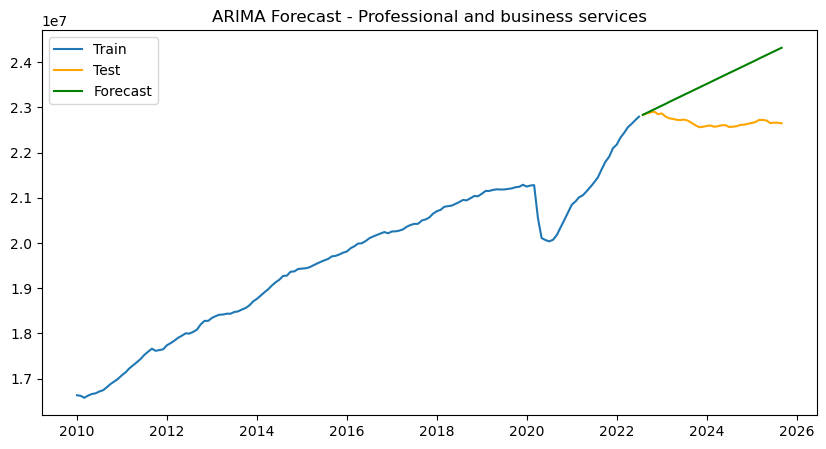

Added results for "Professional and business services" to arima_forecasts.csv successfully!
                               Industry    ARIMA_RMSE  ARIMA_MAPE  \
0                         Manufacturing  7.182910e+04    0.005027   
1  Trade, transportation, and utilities  3.543465e+05    0.011810   
2         Education and health services  1.608741e+06    0.057536   
3    Professional and business services  1.026244e+06    0.039421   

   ARIMA_Growth_%  
0       -0.000051  
1       -0.001944  
2        0.000086  
3        6.679435  


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- Step 1: Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Step 2: Select industry ---
industry = 'Professional and business services'
y = df[industry]

# --- Step 3: Train-test split ---
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# --- Step 4: Fit ARIMA model ---
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# --- Step 5: Forecast ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 6: Evaluate performance ---
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
growth_rate = ((forecast.iloc[-1] - train.iloc[-1]) / train.iloc[-1]) * 100

print(f'{industry} | ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2%}, Growth: {growth_rate:.4f}%')

# --- Step 7: Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title(f'ARIMA Forecast - {industry}')
plt.legend()
plt.show()

# --- Step 8: Prepare result record ---
new_result = pd.DataFrame([{
    'Industry': industry,
    'ARIMA_RMSE': rmse,
    'ARIMA_MAPE': mape,
    'ARIMA_Growth_%': growth_rate
}])

# --- Step 9: Append to existing file ---
existing_file = 'arima_forecasts.csv'

try:
    # Load existing results if file exists
    existing_results = pd.read_csv(existing_file)
    updated_results = pd.concat([existing_results, new_result], ignore_index=True)
except FileNotFoundError:
    # If file doesn't exist, start fresh
    updated_results = new_result

# --- Step 10: Save updated results ---
updated_results.to_csv(existing_file, index=False)
print(f'Added results for "{industry}" to {existing_file} successfully!')
print(updated_results)


## Leisure and hospitality

Leisure and hospitality | ARIMA RMSE: 802450.16, MAPE: 4.19%, Growth: 0.0148%


/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_3279/3137194684.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


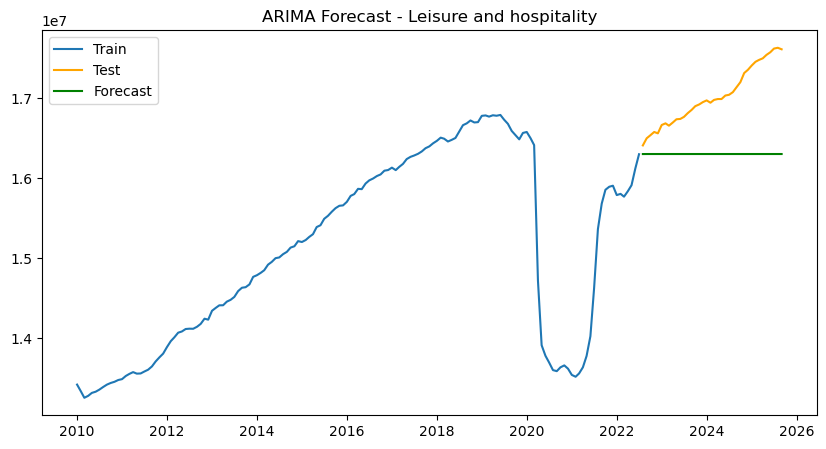

Added results for "Leisure and hospitality" to arima_forecasts.csv successfully!
                               Industry    ARIMA_RMSE  ARIMA_MAPE  \
0                         Manufacturing  7.182910e+04    0.005027   
1  Trade, transportation, and utilities  3.543465e+05    0.011810   
2         Education and health services  1.608741e+06    0.057536   
3    Professional and business services  1.026244e+06    0.039421   
4               Leisure and hospitality  8.024502e+05    0.041867   

   ARIMA_Growth_%  
0       -0.000051  
1       -0.001944  
2        0.000086  
3        6.679435  
4        0.014756  


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- Step 1: Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Step 2: Select industry ---
industry = 'Leisure and hospitality'
y = df[industry]

# --- Step 3: Train-test split ---
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# --- Step 4: Fit ARIMA model ---
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# --- Step 5: Forecast ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 6: Evaluate performance ---
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
growth_rate = ((forecast.iloc[-1] - train.iloc[-1]) / train.iloc[-1]) * 100

print(f'{industry} | ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2%}, Growth: {growth_rate:.4f}%')

# --- Step 7: Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title(f'ARIMA Forecast - {industry}')
plt.legend()
plt.show()

# --- Step 8: Prepare result record ---
new_result = pd.DataFrame([{
    'Industry': industry,
    'ARIMA_RMSE': rmse,
    'ARIMA_MAPE': mape,
    'ARIMA_Growth_%': growth_rate
}])

# --- Step 9: Append to existing file ---
existing_file = 'arima_forecasts.csv'

try:
    # Load existing results if file exists
    existing_results = pd.read_csv(existing_file)
    updated_results = pd.concat([existing_results, new_result], ignore_index=True)
except FileNotFoundError:
    # If file doesn't exist, start fresh
    updated_results = new_result

# --- Step 10: Save updated results ---
updated_results.to_csv(existing_file, index=False)
print(f'Added results for "{industry}" to {existing_file} successfully!')
print(updated_results)


Financial activities | ARIMA RMSE: 133463.82, MAPE: 1.16%, Growth: -0.0130%


/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_3279/1228099952.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


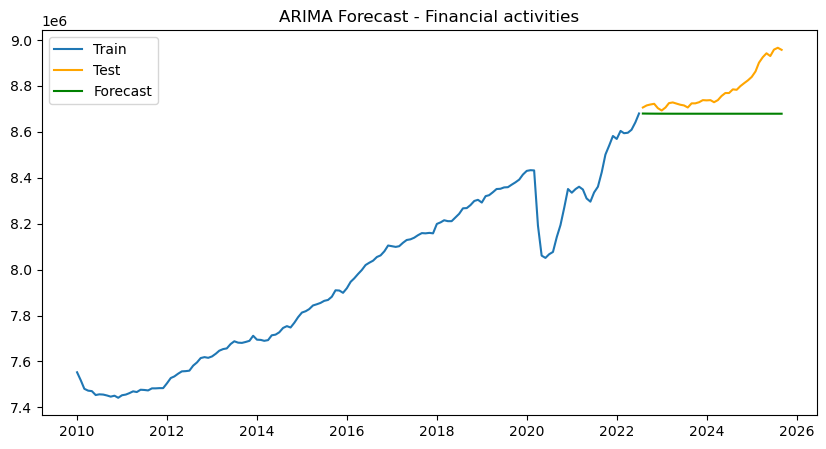

Added results for "Financial activities" to arima_forecasts.csv successfully!
                               Industry    ARIMA_RMSE  ARIMA_MAPE  \
0                         Manufacturing  7.182910e+04    0.005027   
1  Trade, transportation, and utilities  3.543465e+05    0.011810   
2         Education and health services  1.608741e+06    0.057536   
3    Professional and business services  1.026244e+06    0.039421   
4               Leisure and hospitality  8.024502e+05    0.041867   
5                  Financial activities  1.334638e+05    0.011638   

   ARIMA_Growth_%  
0       -0.000051  
1       -0.001944  
2        0.000086  
3        6.679435  
4        0.014756  
5       -0.013010  


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- Step 1: Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Step 2: Select industry ---
industry = 'Financial activities'
y = df[industry]

# --- Step 3: Train-test split ---
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# --- Step 4: Fit ARIMA model ---
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# --- Step 5: Forecast ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 6: Evaluate performance ---
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
growth_rate = ((forecast.iloc[-1] - train.iloc[-1]) / train.iloc[-1]) * 100

print(f'{industry} | ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2%}, Growth: {growth_rate:.4f}%')

# --- Step 7: Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title(f'ARIMA Forecast - {industry}')
plt.legend()
plt.show()

# --- Step 8: Prepare result record ---
new_result = pd.DataFrame([{
    'Industry': industry,
    'ARIMA_RMSE': rmse,
    'ARIMA_MAPE': mape,
    'ARIMA_Growth_%': growth_rate
}])

# --- Step 9: Append to existing file ---
existing_file = 'arima_forecasts.csv'

try:
    # Load existing results if file exists
    existing_results = pd.read_csv(existing_file)
    updated_results = pd.concat([existing_results, new_result], ignore_index=True)
except FileNotFoundError:
    # If file doesn't exist, start fresh
    updated_results = new_result

# --- Step 10: Save updated results ---
updated_results.to_csv(existing_file, index=False)
print(f'Added results for "{industry}" to {existing_file} successfully!')
print(updated_results)


## Natural resources and mining

Natural resources and mining | ARIMA RMSE: 72001.09, MAPE: 3.48%, Growth: -0.0540%


/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_3279/295262434.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


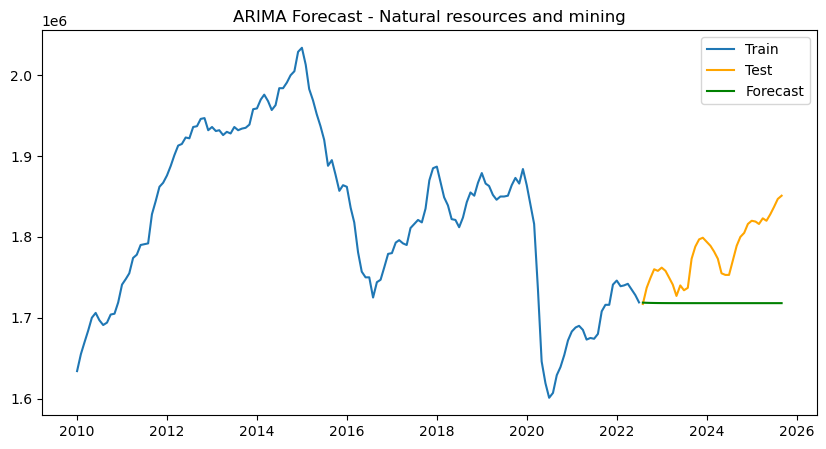

Added results for "Natural resources and mining" to arima_forecasts.csv successfully!
                               Industry    ARIMA_RMSE  ARIMA_MAPE  \
0                         Manufacturing  7.182910e+04    0.005027   
1  Trade, transportation, and utilities  3.543465e+05    0.011810   
2         Education and health services  1.608741e+06    0.057536   
3    Professional and business services  1.026244e+06    0.039421   
4               Leisure and hospitality  8.024502e+05    0.041867   
5                  Financial activities  1.334638e+05    0.011638   
6          Natural resources and mining  7.200109e+04    0.034831   

   ARIMA_Growth_%  
0       -0.000051  
1       -0.001944  
2        0.000086  
3        6.679435  
4        0.014756  
5       -0.013010  
6       -0.054047  


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- Step 1: Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Step 2: Select industry ---
industry = 'Natural resources and mining'
y = df[industry]

# --- Step 3: Train-test split ---
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# --- Step 4: Fit ARIMA model ---
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# --- Step 5: Forecast ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 6: Evaluate performance ---
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
growth_rate = ((forecast.iloc[-1] - train.iloc[-1]) / train.iloc[-1]) * 100

print(f'{industry} | ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2%}, Growth: {growth_rate:.4f}%')

# --- Step 7: Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title(f'ARIMA Forecast - {industry}')
plt.legend()
plt.show()

# --- Step 8: Prepare result record ---
new_result = pd.DataFrame([{
    'Industry': industry,
    'ARIMA_RMSE': rmse,
    'ARIMA_MAPE': mape,
    'ARIMA_Growth_%': growth_rate
}])

# --- Step 9: Append to existing file ---
existing_file = 'arima_forecasts.csv'

try:
    # Load existing results if file exists
    existing_results = pd.read_csv(existing_file)
    updated_results = pd.concat([existing_results, new_result], ignore_index=True)
except FileNotFoundError:
    # If file doesn't exist, start fresh
    updated_results = new_result

# --- Step 10: Save updated results ---
updated_results.to_csv(existing_file, index=False)
print(f'Added results for "{industry}" to {existing_file} successfully!')
print(updated_results)


## Construction

Construction | ARIMA RMSE: 418256.45, MAPE: 4.34%, Growth: -0.0105%


/var/folders/04/b7j0h49j4qlb97tw57d4vybh0000gn/T/ipykernel_3279/1301435517.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DateTime'] = pd.to_datetime(df['DateTime'])
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/rohitha_matwada/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


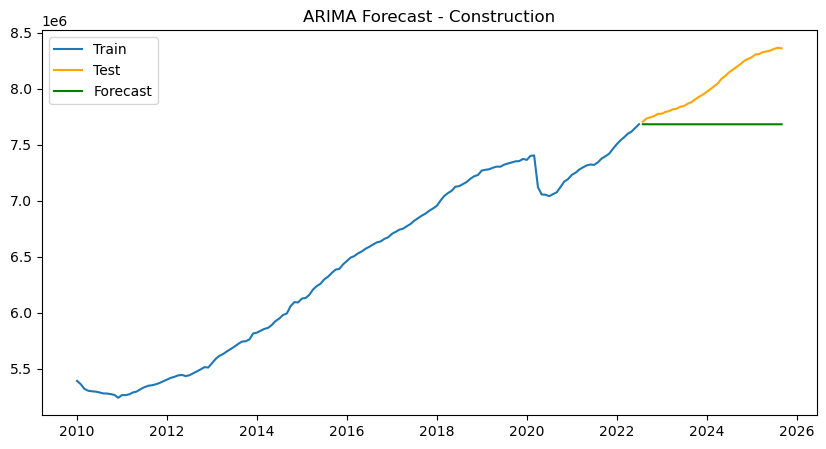

Added results for "Construction" to arima_forecasts.csv successfully!
                               Industry    ARIMA_RMSE  ARIMA_MAPE  \
0                         Manufacturing  7.182910e+04    0.005027   
1  Trade, transportation, and utilities  3.543465e+05    0.011810   
2         Education and health services  1.608741e+06    0.057536   
3    Professional and business services  1.026244e+06    0.039421   
4               Leisure and hospitality  8.024502e+05    0.041867   
5                  Financial activities  1.334638e+05    0.011638   
6          Natural resources and mining  7.200109e+04    0.034831   
7                          Construction  4.182564e+05    0.043406   

   ARIMA_Growth_%  
0       -0.000051  
1       -0.001944  
2        0.000086  
3        6.679435  
4        0.014756  
5       -0.013010  
6       -0.054047  
7       -0.010461  


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- Step 1: Load dataset ---
df = pd.read_csv('us_industry_employment.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')
df.set_index('DateTime', inplace=True)

# --- Step 2: Select industry ---
industry = 'Construction'
y = df[industry]

# --- Step 3: Train-test split ---
train_size = int(len(y) * 0.8)
train, test = y[:train_size], y[train_size:]

# --- Step 4: Fit ARIMA model ---
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# --- Step 5: Forecast ---
forecast = model_fit.forecast(steps=len(test))

# --- Step 6: Evaluate performance ---
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
growth_rate = ((forecast.iloc[-1] - train.iloc[-1]) / train.iloc[-1]) * 100

print(f'{industry} | ARIMA RMSE: {rmse:.2f}, MAPE: {mape:.2%}, Growth: {growth_rate:.4f}%')

# --- Step 7: Plot results ---
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.title(f'ARIMA Forecast - {industry}')
plt.legend()
plt.show()

# --- Step 8: Prepare result record ---
new_result = pd.DataFrame([{
    'Industry': industry,
    'ARIMA_RMSE': rmse,
    'ARIMA_MAPE': mape,
    'ARIMA_Growth_%': growth_rate
}])

# --- Step 9: Append to existing file ---
existing_file = 'arima_forecasts.csv'

try:
    # Load existing results if file exists
    existing_results = pd.read_csv(existing_file)
    updated_results = pd.concat([existing_results, new_result], ignore_index=True)
except FileNotFoundError:
    # If file doesn't exist, start fresh
    updated_results = new_result

# --- Step 10: Save updated results ---
updated_results.to_csv(existing_file, index=False)
print(f'Added results for "{industry}" to {existing_file} successfully!')
print(updated_results)
